In [83]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [84]:
# Loading the dataframe
input_path = Path("..") / 'data' / 'interim' / 'featured_data.csv'
df = pd.read_csv(input_path)
display(df.head(5))
print("Shape of the dataset:\n", df.shape)

,date_index,code_bss,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,sunrise,sunset,...,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d
0,2017-01-01,10906X0039/C2-1,BSS002MNYD,101.85,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2017-01-01T07:19,2017-01-01T16:26,...,1024.5,5.3,0.244,9.2,0.0,87.9,275.8,44.1,90.41,8.05
1,2017-01-02,10906X0039/C2-1,BSS002MNYD,101.89,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2017-01-02T07:19,2017-01-02T16:27,...,1022.0,4.6,0.244,9.2,0.0,87.9,275.8,44.1,90.41,8.05
2,2017-01-03,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2017-01-03T07:19,2017-01-03T16:28,...,1023.5,11.8,0.244,8.9,0.0,87.9,275.8,44.1,90.41,8.05
3,2017-01-04,10906X0039/C2-1,BSS002MNYD,101.98,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2017-01-04T07:19,2017-01-04T16:29,...,1022.9,25.2,0.244,8.8,0.0,87.9,275.8,44.1,90.41,8.05
4,2017-01-05,10906X0039/C2-1,BSS002MNYD,102.01,Valeur reconstituée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2017-01-05T07:19,2017-01-05T16:30,...,1026.5,30.5,0.243,8.7,0.0,87.9,275.8,44.1,90.41,8.05


Shape of the dataset:
 (3402, 25)


In [85]:
df = df.copy()
df = df.set_index("date_index")
df.index = pd.to_datetime(df.index)
display(df.info())
display(df.describe())
display(df.tail())

<class 'pandas.DataFrame'>
DatetimeIndex: 3402 entries, 2017-01-01 to 2026-07-13
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   code_bss                          3402 non-null   str    
 1   bss_id                            3402 non-null   str    
 2   niveau_nappe_eau                  3402 non-null   float64
 3   mode_obtention                    3402 non-null   str    
 4   nom_producteur                    3402 non-null   str    
 5   latitude                          3402 non-null   float64
 6   longitude                         3402 non-null   float64
 7   sunrise                           3402 non-null   str    
 8   sunset                            3402 non-null   str    
 9   daylight_duration                 3402 non-null   float64
 10  precipitation_sum                 3402 non-null   float64
 11  shortwave_radiation_sum           3402 non-null   float64
 12 

None

,niveau_nappe_eau,latitude,longitude,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d
count,3402.000000,3.402000e+03,3.402000e+03,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000,3402.000000
mean,102.790735,4.268570e+01,2.685378e+00,44048.910024,1.710435,15.430973,3.430038,52.564962,1017.082540,13.222986,0.184399,16.439888,11.972252,51.836684,157.211229,-50.193904,-146.206346,16.360647
std,1.117116,7.106472e-15,4.441545e-16,7838.631143,5.791315,7.866721,2.041003,29.938082,6.861055,7.610996,0.071702,5.653710,21.164641,48.571174,102.674766,85.960921,209.432464,5.526975
min,100.060000,4.268570e+01,2.685378e+00,32523.180000,0.000000,0.580000,0.160000,0.000000,989.200000,2.400000,0.046000,5.800000,0.000000,1.000000,25.000000,-241.890000,-537.930000,7.380000
25%,101.940000,4.268570e+01,2.685378e+00,36398.932500,0.000000,8.322500,1.720000,28.000000,1013.700000,7.100000,0.134000,11.400000,1.000000,19.200000,79.450000,-114.467500,-328.600000,11.410000
50%,102.860000,4.268570e+01,2.685378e+00,44038.160000,0.000000,15.090000,3.065000,54.000000,1017.300000,10.800000,0.165000,15.600000,4.700000,35.700000,129.350000,-49.685000,-131.355000,15.515000
75%,103.800000,4.268570e+01,2.685378e+00,51718.617500,0.700000,22.450000,4.950000,77.000000,1021.000000,17.900000,0.239000,21.700000,14.000000,69.600000,210.275000,3.870000,5.695000,21.605000
max,104.630000,4.268570e+01,2.685378e+00,55172.210000,111.200000,30.890000,11.550000,100.000000,1038.500000,41.900000,0.384000,28.300000,243.500000,299.300000,601.900000,271.880000,484.930000,26.500000


,code_bss,bss_id,niveau_nappe_eau,mode_obtention,nom_producteur,latitude,longitude,sunrise,sunset,daylight_duration,...,pressure_msl_mean,wind_speed_10m_mean,soil_moisture_0_to_100cm_mean,soil_temperature_0_to_100cm_mean,P_cum_7d,P_cum_30d,P_cum_90d,Peff_cum_30d,Peff_cum_90d,Temperature_mean_30d
date_index,,,,,,,,,,,,,,,,,,,,,
2026-07-09,10906X0039/C2-1,BSS002MNYD,104.05,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2026-07-09T04:20,2026-07-09T19:28,54522.79,...,1011.0,13.7,0.140,28.3,0.0,3.3,86.0,-240.63,-444.19,23.94
2026-07-10,10906X0039/C2-1,BSS002MNYD,103.99,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2026-07-10T04:20,2026-07-10T19:28,54450.64,...,1011.7,8.4,0.140,28.2,0.0,2.6,86.0,-241.89,-446.09,24.22
2026-07-11,10906X0039/C2-1,BSS002MNYD,103.97,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2026-07-11T04:21,2026-07-11T19:28,54375.17,...,1014.5,8.4,0.139,27.8,0.3,2.9,77.6,-239.79,-458.12,24.47
2026-07-12,10906X0039/C2-1,BSS002MNYD,103.92,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2026-07-12T04:22,2026-07-12T19:27,54296.49,...,1014.4,11.6,0.140,27.9,0.6,3.2,75.8,-235.99,-462.75,24.71
2026-07-13,10906X0039/C2-1,BSS002MNYD,103.86,Valeur mesurée,Syndicat Mixte pour la Protection et la Gestio...,42.685696,2.685378,2026-07-13T04:23,2026-07-13T19:26,54214.72,...,1014.0,10.9,0.139,27.8,0.6,3.2,75.8,-233.65,-464.02,24.93


## Time trend with moving averages

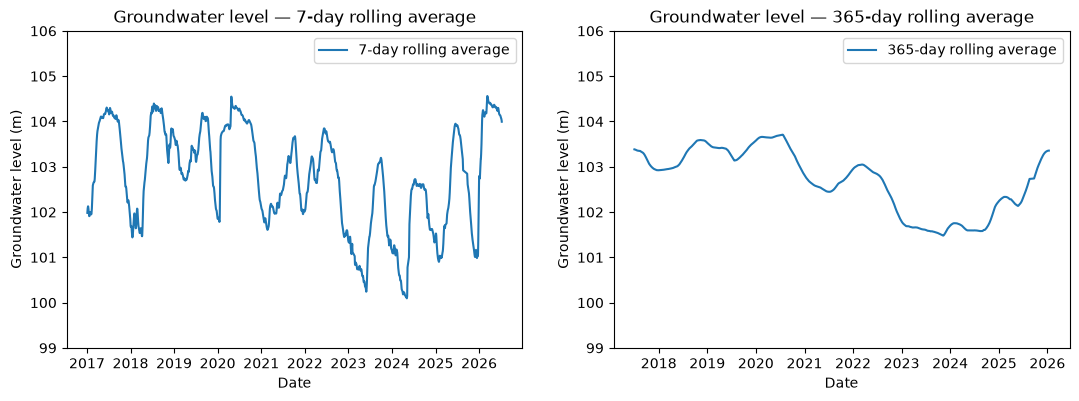

In [86]:
window = [7, 365]
fig = plt.figure(figsize=(20,14))

for i in range(len(window)):
    ax = fig.add_subplot(3,3, i+1)
    #ax.plot(df["niveau_nappe_eau"])
    ax.plot(df["niveau_nappe_eau"].rolling(window[i], center=True).mean(), label=f"{window[i]}-day rolling average")
    ax.set_title(f"Groundwater level — {window[i]}-day rolling average")
    ax.set_xlabel("Date")
    ax.set_ylabel("Groundwater level (m)")
    ax.set_ylim(99, 106)
    ax.legend()

## Seasonality

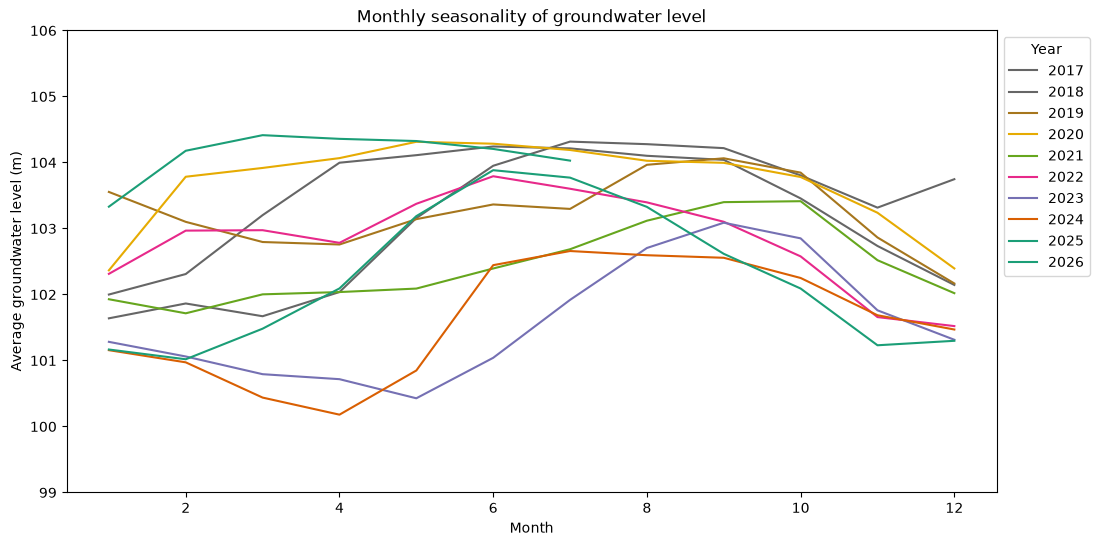

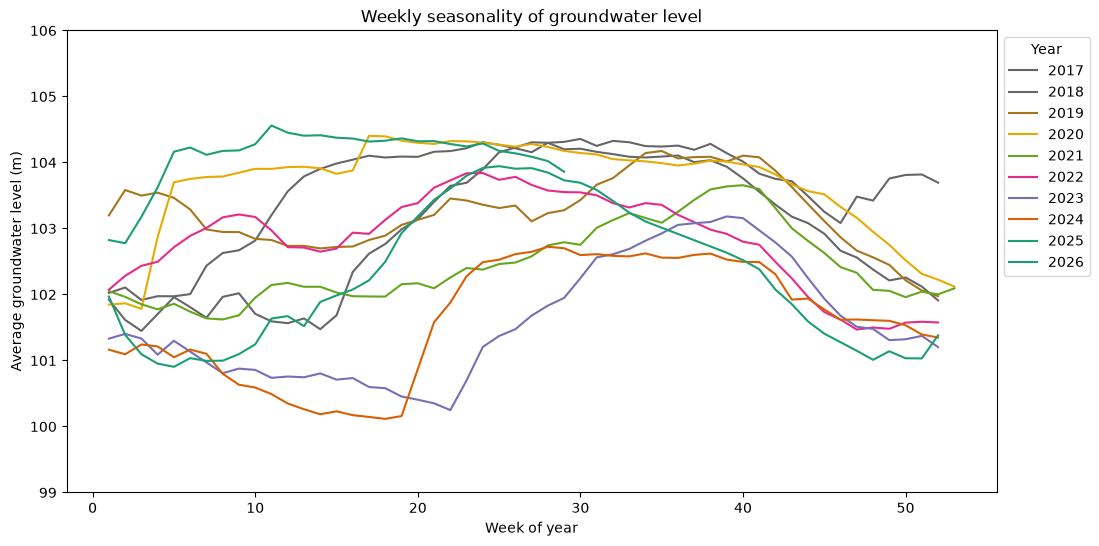

In [87]:
fig1 = plt.figure(figsize=(12,6))
fig2 = plt.figure(figsize=(12,6))
ax1 = fig1.add_subplot(1,1,1)
ax2 = fig2.add_subplot(1,1,1)

yrs = [str(yr) for yr in df.index.year.unique()]
mths = df.index.month.unique()
wks = df.index.isocalendar().week.unique()
colors = plt.cm.Dark2_r(np.linspace(0,1,len(yrs)))

for i in range(len(yrs)):
    yr_df = df[df.index.year == int(yrs[i])]
    mths_agg = yr_df.groupby(yr_df.index.month)["niveau_nappe_eau"].mean()
    wks_agg = yr_df.groupby(yr_df.index.isocalendar().week)["niveau_nappe_eau"].mean()

    ax1.plot(mths_agg.index, mths_agg.values, color=colors[i], label=yrs[i])
    ax2.plot(wks_agg.index, wks_agg.values, color=colors[i], label=yrs[i])

ax1.set_title("Monthly seasonality of groundwater level")
ax1.set_xlabel("Month")
ax1.set_ylabel("Average groundwater level (m)")
ax1.set_ylim(99, 106)
ax1.legend(bbox_to_anchor=(1,1), title="Year")

ax2.set_title("Weekly seasonality of groundwater level")
ax2.set_xlabel("Week of year")
ax2.set_ylabel("Average groundwater level (m)")
ax2.set_ylim(99, 106)
ax2.legend(bbox_to_anchor=(1,1), title="Year")


## Noise 
signal =  trend + seasonality + noise

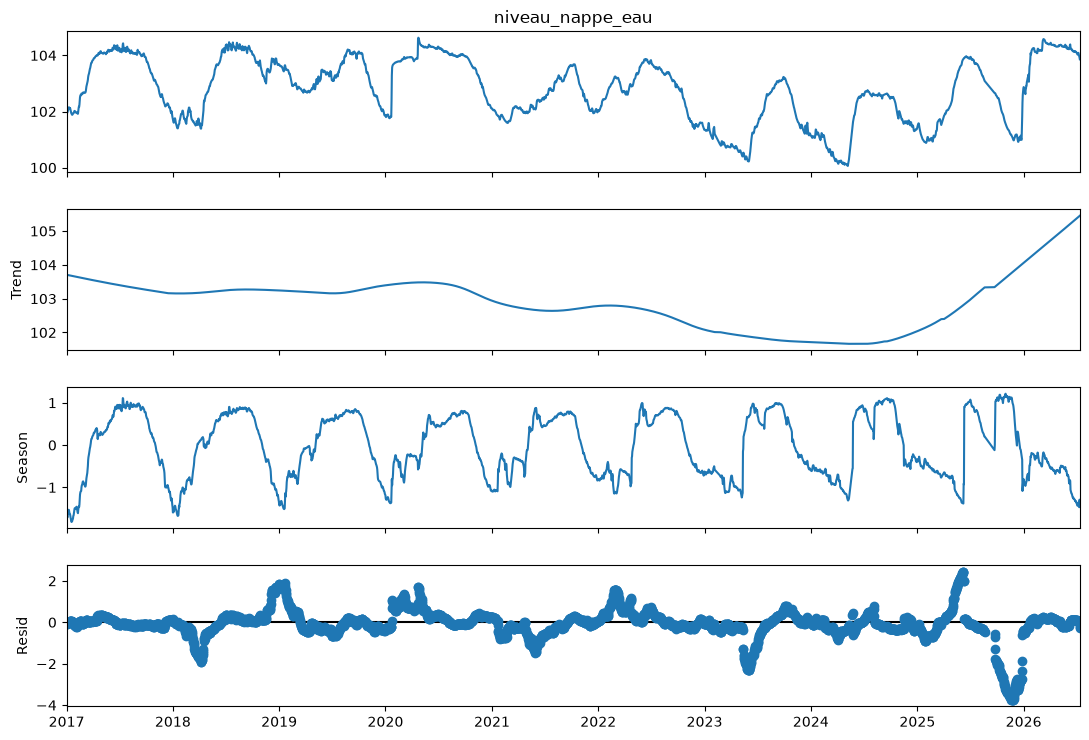

In [88]:
### STL (Seasonal-Trend decomposition using LOESS)
# LOESS = locally weighted regression: fitting a low-degree polynomial to a local window using weighted least squares
from statsmodels.tsa.seasonal import STL


# period=365 for yearly cycle on daily-resolution data 
# robust=True down-weights outliers (weather anomalies, measurement noise)
stl = STL(df["niveau_nappe_eau"], period=365, robust=True)
result = stl.fit()

trend = result.trend # LOESS on the deseasonalized full series to update the trend
seasonal = result.seasonal # LOESS across cycle-subseries (all Januaries, all Februaries, etc.)
noise = result.resid

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

Decision: Choose SLT over classical decomposition
- varying seasonal pattern
- additive model
- handles outliers

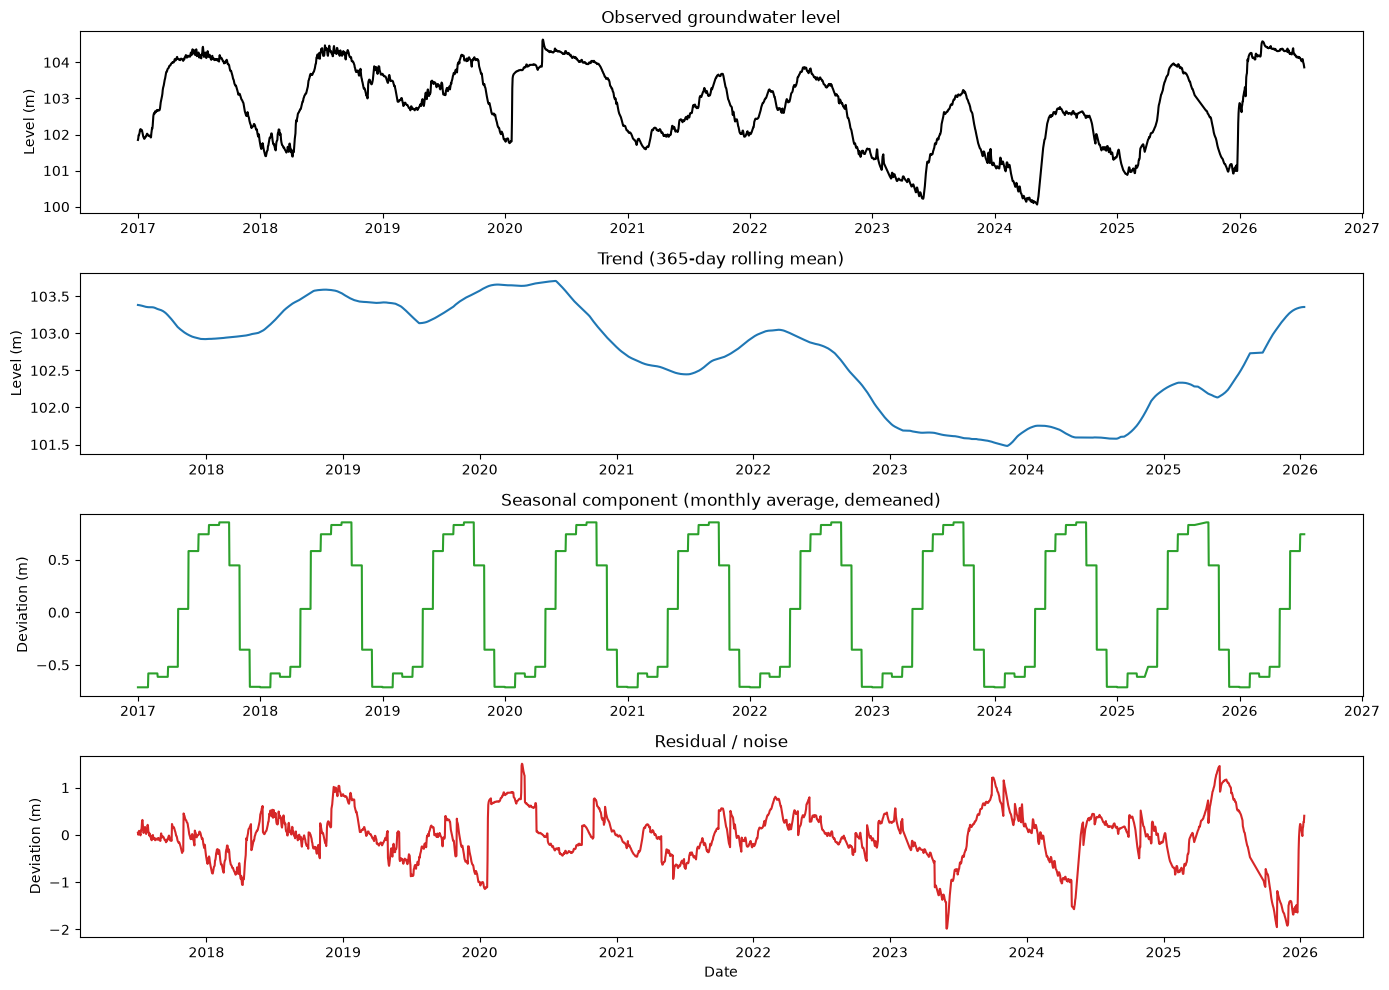

In [89]:
### Manual version : Classical decomposition -> fixed seasonal patterns
# --- Trend: 365-day centered rolling mean, for the yearly period ---
# 
trend = df["niveau_nappe_eau"].rolling(365, center=True).mean()
detrended = df["niveau_nappe_eau"] - trend

# --- Seasonal: average detrended value per month across all years ---
seasonal_avg = detrended.groupby(detrended.index.month).mean()
seasonal_avg = seasonal_avg - seasonal_avg.mean()

# map each date to its month's seasonal value
seasonal = df.index.month.map(seasonal_avg)
seasonal = pd.Series(seasonal, index=df.index)

# --- Residual/noise = signal -  trend - seasonality ---
resid = df["niveau_nappe_eau"] - trend - seasonal

# --- Plot ---
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(4, 1, 1)
ax1.plot(df["niveau_nappe_eau"], color="black")
ax1.set_title("Observed groundwater level")
ax1.set_ylabel("Level (m)")

ax2 = fig.add_subplot(4, 1, 2)
ax2.plot(trend, color="tab:blue")
ax2.set_title("Trend (365-day rolling mean)")
ax2.set_ylabel("Level (m)")

ax3 = fig.add_subplot(4, 1, 3)
ax3.plot(seasonal, color="tab:green")
ax3.set_title("Seasonal component (monthly average, demeaned)")
ax3.set_ylabel("Deviation (m)")

ax4 = fig.add_subplot(4, 1, 4)
ax4.plot(resid, color="tab:red")
ax4.set_title("Residual / noise")
ax4.set_xlabel("Date")
ax4.set_ylabel("Deviation (m)")

fig.tight_layout()
plt.show()

# SPLI
- Standardised Piezometric/Groundwater Level Index
- non-parametric normal-scores transform applied per calendar month
- rank = where a given month's GWL falls relative to all other years' values for that same calendar month

Why not use z-score? A classic z-score is (x − mean)/std, computed directly on the raw values -> valid only if the data are roughly normally distributed. SPLI produces a value on that same standard-normal scale, but gets there through ranks (Gringorten position → inverse normal CDF) instead of mean/std, so it doesn't require the underlying groundwater levels to be normal and it's computed separately per calendar month rather than on the whole series at once.

The Gringorten plotting position is a statistical formula used in hydrology and meteorology to estimate the exceedance probability and return period of extreme events like floods or high winds.
- The equation: \(P_i = \frac{i - 0.44}{n + 0.12}\)
    - the constnat a = 0.44 is chosen empirically
- Variables:
    - i = Rank of the data point (sorted in descending order, with 1 as the largest value)
    - n = Total number of observations or years in the record
    - \(P_{i}\) = Estimated cumulative probability or plotting position
- Purpose: It reduces bias when plotting extreme environmental or hydrological data

In [104]:
from scipy.stats import norm

# Resample raw GWL to monthly mean
gwl_monthly = df["niveau_nappe_eau"].resample(rule="MS").mean()
display(gwl_monthly.head())
print("Months with 0 daily observations: ", gwl_monthly.isna().sum())

# Group gwl_monthly by calendar month (12 groups)
month_groups = gwl_monthly.groupby(gwl_monthly.index.month)
print(month_groups.size())
display("Ranks of all Januaries: ", month_groups.get_group(1).rank())

# Rank within each group + Gringorten plotting position
# .transform() returns a result the same shape and index as the original gwl_monthly
ranks = month_groups.transform("rank") # takes the method name as a bare string
n = month_groups.transform("count")
p = (ranks - 0.44) / (n + 1 - 2*0.44)

# Inverse-normal transformation of p (norm.ppf) → monthly SPLI
# CDF (cumulative distribution function): gives the probability that a random variable is ≤ some value 
# PPF (percent-point function) = inverse of CDF => given a probability, returns the value (z-score) below which that probability of the distribution falls
# Reassemble into one chronological monthly series
spli_monthly = pd.Series(norm.ppf(p), index=p.index, name="SPLI")
spli_monthly_causal = spli_monthly.shift(1)
display("SPLI: ", spli_monthly.describe())

# Broadcast back to daily (forward-fill each month's SPLI onto its days) so it merges cleanly with dataset
spli_daily = spli_monthly.reindex(df.index, method="ffill")
spli_daily.rename("SPLI_retro")
spli_daily_causal = spli_monthly_causal.reindex(df.index, method="ffill")
spli_daily_causal.rename("SPLI_feature")
display("Daily SPLI: ", spli_daily.tail(35))
display("Daily SPLI from past month: ", spli_daily_causal.tail(35))


date_index
2017-01-01    101.999355
2017-02-01    102.310000
2017-03-01    103.202258
2017-04-01    103.996667
2017-05-01    104.110968
Freq: MS, Name: niveau_nappe_eau, dtype: float64

Months with 0 daily observations:  0
date_index
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8      9
9      9
10     9
11     9
12     9
Name: niveau_nappe_eau, dtype: int64


'Ranks of all Januaries: '

date_index
2017-01-01     6.0
2018-01-01     4.0
2019-01-01    10.0
2020-01-01     8.0
2021-01-01     5.0
2022-01-01     7.0
2023-01-01     3.0
2024-01-01     1.0
2025-01-01     2.0
2026-01-01     9.0
Freq: 12MS, Name: niveau_nappe_eau, dtype: float64

'SPLI: '

count    1.150000e+02
mean     1.877725e-16
std      9.156436e-01
min     -1.595180e+00
25%     -6.651902e-01
50%      0.000000e+00
75%      6.651902e-01
max      1.595180e+00
Name: SPLI, dtype: float64

'Daily SPLI: '

date_index
2026-06-09    0.665190
2026-06-10    0.665190
2026-06-11    0.665190
2026-06-12    0.665190
2026-06-13    0.665190
2026-06-14    0.665190
2026-06-15    0.665190
2026-06-16    0.665190
2026-06-17    0.665190
2026-06-18    0.665190
2026-06-19    0.665190
2026-06-20    0.665190
2026-06-21    0.665190
2026-06-22    0.665190
2026-06-23    0.665190
2026-06-24    0.665190
2026-06-25    0.665190
2026-06-26    0.665190
2026-06-27    0.665190
2026-06-28    0.665190
2026-06-29    0.665190
2026-06-30    0.665190
2026-07-01    0.380523
2026-07-02    0.380523
2026-07-03    0.380523
2026-07-04    0.380523
2026-07-05    0.380523
2026-07-06    0.380523
2026-07-07    0.380523
2026-07-08    0.380523
2026-07-09    0.380523
2026-07-10    0.380523
2026-07-11    0.380523
2026-07-12    0.380523
2026-07-13    0.380523
Name: SPLI, dtype: float64

'Daily SPLI from past month: '

date_index
2026-06-09    1.59518
2026-06-10    1.59518
2026-06-11    1.59518
2026-06-12    1.59518
2026-06-13    1.59518
2026-06-14    1.59518
2026-06-15    1.59518
2026-06-16    1.59518
2026-06-17    1.59518
2026-06-18    1.59518
2026-06-19    1.59518
2026-06-20    1.59518
2026-06-21    1.59518
2026-06-22    1.59518
2026-06-23    1.59518
2026-06-24    1.59518
2026-06-25    1.59518
2026-06-26    1.59518
2026-06-27    1.59518
2026-06-28    1.59518
2026-06-29    1.59518
2026-06-30    1.59518
2026-07-01    0.66519
2026-07-02    0.66519
2026-07-03    0.66519
2026-07-04    0.66519
2026-07-05    0.66519
2026-07-06    0.66519
2026-07-07    0.66519
2026-07-08    0.66519
2026-07-09    0.66519
2026-07-10    0.66519
2026-07-11    0.66519
2026-07-12    0.66519
2026-07-13    0.66519
Name: SPLI, dtype: float64

In [102]:
spli_daily.isna().sum()

np.int64(0)

In [ ]:
df["SPLI_feature"] = spli_daily_causal
df["SPLI_retro"] = spli_daily

Observation: with forward-fill method in SPLI calculation, the feature for early-January is built partly from late-January data we couldn't have had yet at prediction time. ("fuite temporelle... on ne connaît pas la pluie de J+14").
Decision: 
- SPLI (retrospective) = each month's own aggregate -> use for descriptive analysis and figures; 
- SPLI (as predictive feature) = shifted by one month -> use only in the row-level matrix that feeds forecasting models.


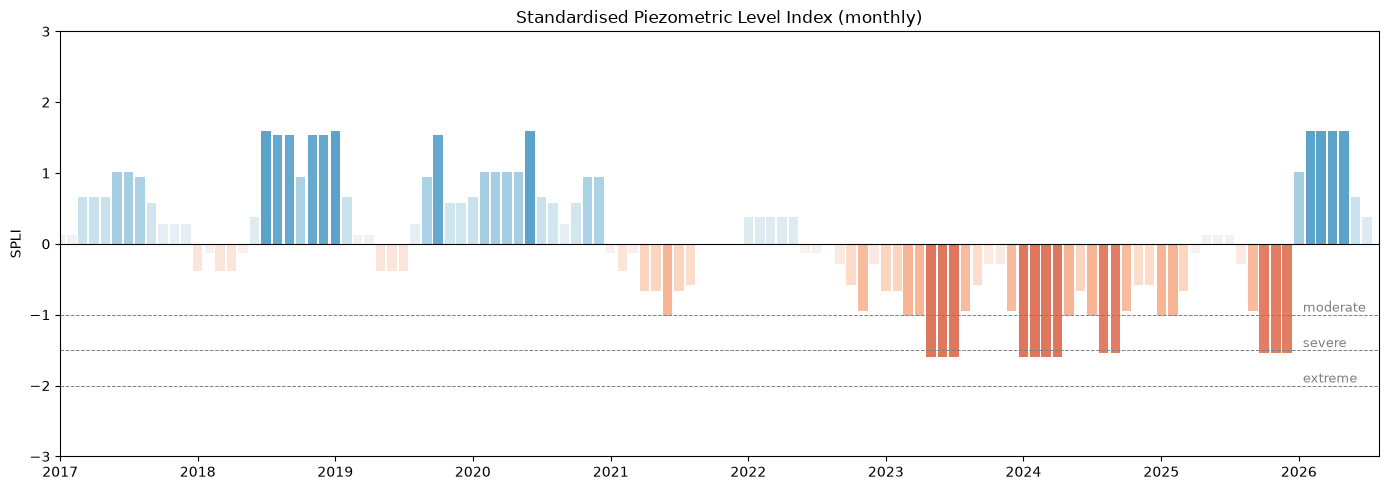

In [117]:
## Visualization

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))

# Diverging colormap: blue = higher SPLI than median over calendar month, red = drier, centered on 0
cmap = plt.get_cmap("RdBu")
norm = mcolors.TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
colors = cmap(norm(spli_monthly.values))

ax.bar(spli_monthly.index, spli_monthly.values, width=25, color=colors, edgecolor="none")
#ax.plot(spli_monthly.index, spli_monthly.values, color="black", linewidth=0.8, alpha=0.6)

# Severity reference lines (standard SPI/SGI convention)
for y, label in [(-1, "moderate"), (-1.5, "severe"), (-2, "extreme")]:
    ax.axhline(y, color="grey", linestyle="--", linewidth=0.7)
    ax.text(spli_monthly.index[-7], y, f" {label}", va="bottom", fontsize=9, color="grey")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("SPLI")
ax.set_title("Standardised Piezometric Level Index (monthly)")
ax.set_ylim(-3, 3)
ax.set_xlim('2017-01-01', '2026-08-01')

plt.tight_layout()
plt.show()

- SPLI = 0 means => month's groundwater level sits at the median of all historical observations for that same calendar month -> neither wetter nor drier than normal.
- short scales SPLI (1 mo) catch flash droughts/soil moisture; long scales (12 mo) catch hydrological/groundwater deficits. Your groundwater SPLI naturally behaves like a long-scale index (it's low-pass filtered by the aquifer)